In [29]:
import os, pickle

from physics.simulation import msq, mcfm
from physics.hzz import zpair, zz4l
from physics.hstar import c6

from models import rolypoly

import numpy as np
import hist
import matplotlib.pyplot as plt
import pandas as pd

import torch

In [30]:
META_DIR = '../jobs/rolypoly/refactor-four-INT'
COMPONENT = msq.Component.INT
COMPONENT_FILE = msq.Component.SIG

SAMPLE_SIZE = 200000

#SIG
CHECKPOINTS = [(26,0.08),
               (181,'0.00'),
               (180,0.12),
               (126,'0.00')]

#SBI
CHECKPOINTS = [(190,0.34),
               (79,0.64),
               (97,0.45),
               (95,'0.50')]

#INT
CHECKPOINTS = [(145,"0.06"),
               (149,"0.12"),]

FEATURES = ['mandelstam_s', 'mandelstam_t', 'mandelstam_u']

SEED = 42

DIRS = [os.path.join(META_DIR, f'coeff_{i}') for i in range(1,5)] if COMPONENT != msq.Component.INT else [os.path.join(META_DIR, f'coeff_{i}') for i in range(1,3)]
CHECKPOINT_DIRS = [os.path.join(DIRS[i], 'checkpoints', f'checkpoint-rolypoly-epoch={CHECKPOINTS[i][0]}-val_loss={CHECKPOINTS[i][1]}.ckpt') for i in range(len(DIRS))]
SAMPLE_FILE = os.path.join('../..', {msq.Component.SBI:'ggZZ2e2m_sbi.csv',msq.Component.SIG:'ggZZ2e2m_sig.csv',msq.Component.INT:'ggZZ2e2m_int.csv',msq.Component.BKG:'ggZZ2e2m_bkg.csv'}[COMPONENT_FILE])
CMP_NAME = {msq.Component.SBI:'SBI',msq.Component.SIG:'SIG',msq.Component.BKG:'BKG',msq.Component.INT:'INT'}[COMPONENT]

In [31]:
events = mcfm.from_csv(cross_section=0.2, file_path=SAMPLE_FILE, n_rows=1.2*SAMPLE_SIZE).reweight(COMPONENT_FILE, COMPONENT)

zcand = zpair.ZPairCandidate(algorithm='leastsquare')
zmasses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))

angles = zz4l.AngularVariables()
fourlep = zz4l.FourLeptonSystem()
mandelstam = zz4l.MandelstamVariables()

events_processed = events.calculate(zcand).filter(zmasses).calculate(mandelstam).calculate(fourlep).calculate(angles)[:SAMPLE_SIZE]

0.12066544832123541
Weights > 0.0: 0.19999999999999996


In [32]:
events_processed.weights

0        -8.723746e-08
1        -1.938822e-06
2        -1.373845e-06
3        -2.254377e-07
4        -5.782326e-07
              ...     
199995   -1.362539e-06
199996   -4.714235e-07
199997   -2.665955e-06
199998   -2.654290e-07
199999   -1.024071e-07
Length: 200000, dtype: float64

In [33]:
c6_mod = c6.Modifier(baseline=COMPONENT, events=events_processed, c6_values=[-5,-1,0,1,5]) if COMPONENT!=msq.Component.INT else c6.Modifier(baseline=COMPONENT, events=events_processed, c6_values=[-5,0,5])

datasets = []

unweighted_indices = events_processed.weights.sample(n=SAMPLE_SIZE, replace=True, weights=np.ones_like(events_processed.weights), random_state=SEED).index

for i in range(len(DIRS)):
    coefficient = c6_mod.coefficients[:,i+1]
    X = events_processed.kinematics[FEATURES].to_numpy()

    with open(os.path.join(DIRS[i], 'scaler_X.pkl'), 'rb') as f:
        scaler_X = pickle.load(f)

    X = torch.tensor(scaler_X.transform(X), dtype=torch.float32).cpu()
    y = coefficient

    print(X.shape, y.shape)

    dataset = torch.utils.data.TensorDataset(X, torch.tensor(y, dtype=torch.float32))
    datasets.append(dataset)

#events_unweighted = mcfm.Process(events_processed.kinematics.loc[unweighted_indices].reset_index(drop=True),
#                                 events_processed.components.loc[unweighted_indices].reset_index(drop=True),
#                                 events_processed.weights.loc[unweighted_indices].reset_index(drop=True))

torch.Size([200000, 3]) (200000,)
torch.Size([200000, 3]) (200000,)


In [34]:
models = [rolypoly.ROLYPOLY.load_from_checkpoint(checkpoint_path=CHECKPOINT_DIRS[i]) for i in range(len(DIRS))]

In [35]:
predictions = np.array([pickle.load(open(os.path.join(DIRS[i], 'scaler_y.pkl'), 'rb')).inverse_transform(models[i](datasets[i].tensors[0]).detach().numpy()) for i in range(len(DIRS))]).T.squeeze(0)

In [36]:
predicted_coefficients = np.concatenate([np.ones((predictions.shape[0],1)), predictions], axis=1)
true_coefficients = np.concatenate([np.ones((predictions.shape[0],1)), np.array([datasets[i].tensors[1].detach().numpy() for i in range(len(datasets))]).T], axis=1)

In [37]:
c6_value = -10

reweight_pred = np.apply_along_axis(lambda x: np.polyval(x, c6_value), 1, predicted_coefficients[:, ::-1])
reweight_truth = np.apply_along_axis(lambda x: np.polyval(x, c6_value), 1, true_coefficients[:, ::-1])

/tmp/ipykernel_212330/3762168332.py:54: RuntimeWarning: invalid value encountered in divide
  ax2.errorbar(hist_sm.axes[0].centers, hist_sm.values()/hist_sm.values(), yerr=np.abs(np.sqrt(hist_sm.variances())/hist_sm.values()), color='black', linestyle='--', drawstyle='steps-mid', label=f'{CMP_NAME}', alpha=0.8)
/tmp/ipykernel_212330/3762168332.py:55: RuntimeWarning: invalid value encountered in divide
  ax2.errorbar(hist_sm.axes[0].centers, hist_c6_pred.values()/hist_sm.values(), yerr=np.sqrt((np.sqrt(hist_c6_pred.variances())/hist_sm.values())**2 + (- np.sqrt(hist_sm.variances())*hist_c6_pred.values()/hist_sm.values()**2)**2), color='r', drawstyle='steps-mid', label=f'{CMP_NAME}(SM) -> {CMP_NAME}(c6={c6_value}) (prediction)')
/tmp/ipykernel_212330/3762168332.py:56: RuntimeWarning: invalid value encountered in divide
  ax2.errorbar(hist_sm.axes[0].centers, hist_c6_truth.values()/hist_sm.values(), yerr=np.sqrt((np.sqrt(hist_c6_truth.variances())/hist_sm.values())**2 + (- np.sqrt(hist_sm

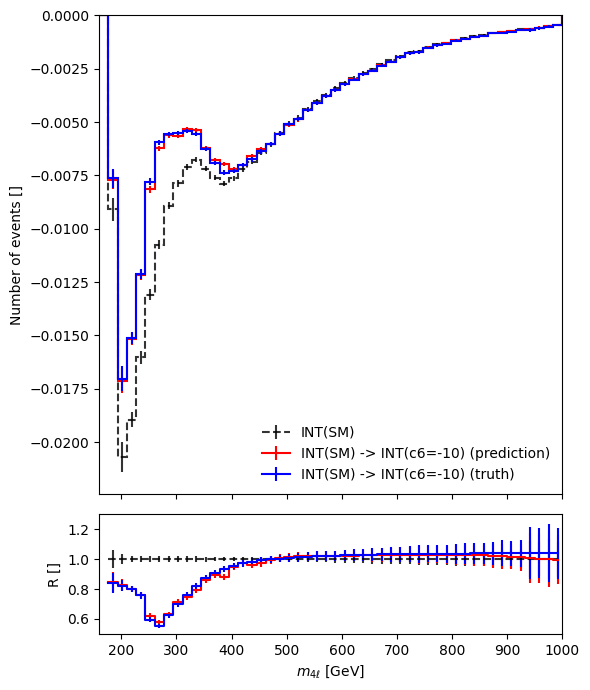

In [38]:
index = 7

PLOT_FEATURES = ['cth_star', 'cth_1', 'cth_2', 'phi_1', 'phi', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity']

X = events_processed.kinematics[PLOT_FEATURES].to_numpy()

kin_var = X[:,index]
label = ['$\mathrm{cos}(\\theta^*)$ []',
         '$\mathrm{cos}(\\theta_1)$ []',
         '$\mathrm{cos}(\\theta_2)$ []',
         '$\phi$ []',
         '$\phi_1$ []',
         '$m_{Z1}$ [GeV]',
         '$m_{Z2}$ [GeV]',
         '$m_{4\ell}$ [GeV]',
         '$y_{4\ell}$ []'][index]
bounds = [[-1,1],
          [-1,1],
          [-1,1],
          [-np.pi,np.pi],
          [-np.pi,np.pi],
          [70,115],
          [70,115],
          [160,1000],
          [-2.4,2.4]][index]


BINS=50

hist_sm = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_sm.fill(kin_var, weight=events_processed.weights.to_numpy())

hist_c6_pred = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_c6_pred.fill(kin_var, weight=events_processed.weights.to_numpy()*reweight_pred)

hist_c6_truth = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_c6_truth.fill(kin_var, weight=events_processed.weights.to_numpy()*reweight_truth)

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

hist_sm.plot(ax=ax1, color='k', linestyle='--', label=f'{CMP_NAME}(SM)', alpha=0.8, yerr=np.sqrt(hist_sm.variances()))
hist_c6_pred.plot(ax=ax1, color='r', label=f'{CMP_NAME}(SM) -> {CMP_NAME}(c6={c6_value}) (prediction)', yerr=np.sqrt(hist_c6_pred.variances()))
hist_c6_truth.plot(ax=ax1, color='b', label=f'{CMP_NAME}(SM) -> {CMP_NAME}(c6={c6_value}) (truth)', yerr=np.sqrt(hist_c6_truth.variances()))

ax1.set_ylabel('Number of events []')
#ax1.set_yscale('log')
ax1.set_xlim(*bounds)
ax1.set_xlabel('')

ax1.legend(frameon=False)

ax2.errorbar(hist_sm.axes[0].centers, hist_sm.values()/hist_sm.values(), yerr=np.abs(np.sqrt(hist_sm.variances())/hist_sm.values()), color='black', linestyle='--', drawstyle='steps-mid', label=f'{CMP_NAME}', alpha=0.8)
ax2.errorbar(hist_sm.axes[0].centers, hist_c6_pred.values()/hist_sm.values(), yerr=np.sqrt((np.sqrt(hist_c6_pred.variances())/hist_sm.values())**2 + (- np.sqrt(hist_sm.variances())*hist_c6_pred.values()/hist_sm.values()**2)**2), color='r', drawstyle='steps-mid', label=f'{CMP_NAME}(SM) -> {CMP_NAME}(c6={c6_value}) (prediction)')
ax2.errorbar(hist_sm.axes[0].centers, hist_c6_truth.values()/hist_sm.values(), yerr=np.sqrt((np.sqrt(hist_c6_truth.variances())/hist_sm.values())**2 + (- np.sqrt(hist_sm.variances())*hist_c6_truth.values()/hist_sm.values()**2)**2), color='b', drawstyle='steps-mid', label=f'{CMP_NAME}(SM) -> {CMP_NAME}(c6={c6_value}) (truth)')
         
ax2.set_xlabel(label)
ax2.set_ylabel('R []')
#ax2.set_yscale('log')
ax2.set_ybound(0.5,1.3)
ax2.set_xlim(*bounds)
fig.tight_layout()

plt.show()